In [2]:
from google.colab import files
import tensorflow as tf
print("TF version:", tf.__version__)

TF version: 2.20.0


In [5]:
import os
import warnings
import numpy as np
import pandas as pd
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from collections import Counter

import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 70)
print("  MODELO GRD — HOSPITAL EL PINO v2")
print(f"  Timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  TF Version: {tf.__version__}")
print("=" * 70)


# CONFIGURACIÓN
CONFIG = {
    "data_path"   : "/content/dataset_elpino_brillibrilli (2).csv", # Corrected file path
    "sep"         : ";",
    "target_grd"  : "target_grd",

    # Columnas numéricas
    "cols_numeric": ["Edad", "Sexo_bin"],

    # Columnas categóricas
    "cols_cat": [
        "Diag 01 Principal (cod+des)_cod",
        "Diag 02 Secundario (cod+des)_cod",
        "Diag 03 Secundario (cod+des)_cod",
        "Diag 04 Secundario (cod+des)_cod",
        "Diag 05 Secundario (cod+des)_cod",
        "Diag 06 Secundario (cod+des)_cod",
        "Diag 07 Secundario (cod+des)_cod",
        "Diag 08 Secundario (cod+des)_cod",
        "Diag 09 Secundario (cod+des)_cod",
        "Diag 10 Secundario (cod+des)_cod",
        "Diag 11 Secundario (cod+des)_cod",
        "Diag 12 Secundario (cod+des)_cod",
        "Diag 13 Secundario (cod+des)_cod",
        "Diag 14 Secundario (cod+des)_cod",
        "Diag 15 Secundario (cod+des)_cod",
        "Diag 16 Secundario (cod+des)_cod",
        "Diag 17 Secundario (cod+des)_cod",
        "Diag 18 Secundario (cod+des)_cod",
        "Diag 19 Secundario (cod+des)_cod",
        "Diag 20 Secundario (cod+des)_cod",
        "Diag 21 Secundario (cod+des)_cod",
        "Diag 22 Secundario (cod+des)_cod",
        "Diag 23 Secundario (cod+des)_cod",
        "Diag 24 Secundario (cod+des)_cod",
        "Diag 25 Secundario (cod+des)_cod",
        "Diag 26 Secundario (cod+des)_cod",
        "Diag 27 Secundario (cod+des)_cod",
        "Diag 28 Secundario (cod+des)_cod",
        "Diag 29 Secundario (cod+des)_cod",
        "Diag 30 Secundario (cod+des)_cod",
        "Diag 31 Secundario (cod+des)_cod",
        "Diag 32 Secundario (cod+des)_cod",
        "Diag 33 Secundario (cod+des)_cod",
        "Diag 34 Secundario (cod+des)_cod",
        "Diag 35 Secundario (cod+des)_cod",
        "Proced 01 Principal (cod+des)_cod",
        "Proced 02 Secundario (cod+des)_cod",
        "Proced 03 Secundario (cod+des)_cod",
        "Proced 04 Secundario (cod+des)_cod",
        "Proced 05 Secundario (cod+des)_cod",
        "Proced 06 Secundario (cod+des)_cod",
        "Proced 07 Secundario (cod+des)_cod",
        "Proced 08 Secundario (cod+des)_cod",
        "Proced 09 Secundario (cod+des)_cod",
        "Proced 10 Secundario (cod+des)_cod",
        "Proced 11 Secundario (cod+des)_cod",
        "Proced 12 Secundario (cod+des)_cod",
        "Proced 13 Secundario (cod+des)_cod",
        "Proced 14 Secundario (cod+des)_cod",
        "Proced 15 Secundario (cod+des)_cod",
        "Proced 16 Secundario (cod+des)_cod",
        "Proced 17 Secundario (cod+des)_cod",
        "Proced 18 Secundario (cod+des)_cod",
        "Proced 19 Secundario (cod+des)_cod",
        "Proced 20 Secundario (cod+des)_cod",
        "Proced 21 Secundario (cod+des)_cod",
        "Proced 22 Secundario (cod+des)_cod",
        "Proced 23 Secundario (cod+des)_cod",
        "Proced 24 Secundario (cod+des)_cod",
        "Proced 25 Secundario (cod+des)_cod",
        "Proced 26 Secundario (cod+des)_cod",
        "Proced 27 Secundario (cod+des)_cod",
        "Proced 28 Secundario (cod+des)_cod",
        "Proced 29 Secundario (cod+des)_cod",
        "Proced 30 Secundario (cod+des)_cod",
    ],

    # Arquitectura
    "embedding_dim"  : 16,
    "dense_units"    : [512, 256, 128, 64],
    "dropout_rate"   : 0.35,

    # Entrenamiento
    "batch_size"     : 512,
    "epochs"         : 150,
    "learning_rate"  : 3e-4,
    "test_size"      : 0.20,
    "val_size"       : 0.15,

    # Callbacks
    "es_patience"    : 15,
    "rlr_patience"   : 7,
    "rlr_factor"     : 0.5,
    "min_lr"         : 1e-6,
    "checkpoint"     : "mejor_modelo_grd.keras",
}


# 1. CARGA DE DATOS

print("\n[1/5] Cargando datos...")
df = pd.read_csv(CONFIG["data_path"], sep=CONFIG["sep"], low_memory=False)
print(f"  → Shape: {df.shape}")

# Filtrar solo columnas que existen
cols_cat = [c for c in CONFIG["cols_cat"] if c in df.columns]
cols_num = [c for c in CONFIG["cols_numeric"] if c in df.columns]
print(f"  → Columnas categóricas encontradas : {len(cols_cat)}")
print(f"  → Columnas numéricas encontradas   : {cols_num}")
print(f"  → Clases GRD únicas               : {df[CONFIG['target_grd']].nunique()}")


# 2. PREPROCESAMIENTO
print("\n[2/5] Preprocesando...")

for col in cols_cat:
    df[col] = df[col].fillna("MISSING").astype(str).str.strip().str.upper()

for col in cols_num:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col].fillna(df[col].median(), inplace=True)

# Eliminar filas sin target
df.dropna(subset=[CONFIG["target_grd"]], inplace=True)
print(f"  → Shape limpio: {df.shape}")

# Encoding del target GRD
le_grd = LabelEncoder()
y_raw  = le_grd.fit_transform(df[CONFIG["target_grd"]].astype(str))
n_classes = len(le_grd.classes_)
y_ohe = tf.keras.utils.to_categorical(y_raw, num_classes=n_classes)
print(f"  → Clases GRD codificadas: {n_classes}")

# Encoding de features
col_encoders   = {}
col_vocab_sizes = {}
X_cat_list     = []

for col in cols_cat:
    le  = LabelEncoder()
    enc = le.fit_transform(df[col])
    col_encoders[col]    = le
    col_vocab_sizes[col] = len(le.classes_) + 1
    X_cat_list.append(enc.reshape(-1, 1))

# Estandarizar
scaler  = StandardScaler()
X_num   = scaler.fit_transform(df[cols_num].values)
print(f"  → Features numéricas shape: {X_num.shape}")

# 3. SPLIT
print("\n[3/5] Dividiendo datos...")

counts     = pd.Series(y_raw).value_counts()
clases_ok  = counts[counts >= 2].index
mask_valid = np.isin(y_raw, clases_ok)

X_cat_list = [arr[mask_valid] for arr in X_cat_list]
X_num      = X_num[mask_valid]
y_ohe      = y_ohe[mask_valid]
y_raw      = y_raw[mask_valid]

print(f"  → Muestras tras filtrar clases únicas: {mask_valid.sum():,}")
print(f"  → Clases GRD restantes: {len(clases_ok)}")

n       = mask_valid.sum()
indices = np.arange(n)

idx_trainval, idx_test = train_test_split(
    indices, test_size=CONFIG["test_size"], random_state=SEED, stratify=y_raw
)
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=CONFIG["val_size"],
    random_state=SEED, stratify=y_raw[idx_trainval]
)

print(f"  → Train: {len(idx_train):,}  |  Val: {len(idx_val):,}  |  Test: {len(idx_test):,}")

def make_inputs(idx):
    return [X_cat_list[i][idx] for i in range(len(cols_cat))] + [X_num[idx]]

X_train, X_val, X_test = make_inputs(idx_train), make_inputs(idx_val), make_inputs(idx_test)
y_train, y_val, y_test = y_ohe[idx_train], y_ohe[idx_val], y_ohe[idx_test]

# 4. MODELO
print("\n[4/5] Construyendo modelo...")

def build_model():
    cat_inputs    = []
    embed_outputs = []

    for i, col in enumerate(cols_cat):
        vocab   = col_vocab_sizes[col]
        emb_dim = min(CONFIG["embedding_dim"], max(4, vocab // 4))
        inp = Input(shape=(1,), name=f"in_{i}")
        emb = layers.Embedding(vocab, emb_dim, name=f"emb_{i}")(inp)
        flat = layers.Flatten()(emb)
        cat_inputs.append(inp)
        embed_outputs.append(flat)

    num_input = Input(shape=(X_num.shape[1],), name="in_num")
    x = layers.Concatenate()(embed_outputs + [num_input])

    for i, units in enumerate(CONFIG["dense_units"]):
        x = layers.Dense(units, name=f"dense_{i}")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.Dropout(CONFIG["dropout_rate"])(x)

    out = layers.Dense(n_classes, activation="softmax", name="output_grd")(x)

    model = Model(inputs=cat_inputs + [num_input], outputs=out, name="GRD_ElPino")
    model.compile(
        optimizer=Adam(CONFIG["learning_rate"]),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_model()
model.summary()
print(f"\n  → Parámetros entrenables: {model.count_params():,}")

callbacks = [
    EarlyStopping(monitor="val_loss", patience=CONFIG["es_patience"],
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=CONFIG["rlr_factor"],
                      patience=CONFIG["rlr_patience"], min_lr=CONFIG["min_lr"], verbose=1),
    ModelCheckpoint(CONFIG["checkpoint"], monitor="val_loss",
                    save_best_only=True, verbose=0),
]

# 5. ENTRENAMIENTO
print("\n[5/5] Entrenando...")
history = model.fit(
    x               = X_train,
    y               = y_train,
    validation_data = (X_val, y_val),
    epochs          = CONFIG["epochs"],
    batch_size      = CONFIG["batch_size"],
    callbacks       = callbacks,
    verbose         = 1,
)
# 6. EVALUACIÓN
print("\nEvaluando en Test Set...")
pred_probs = model.predict(X_test, batch_size=CONFIG["batch_size"], verbose=0)
pred_grd   = np.argmax(pred_probs, axis=1)
true_grd   = np.argmax(y_test,     axis=1)

acc  = accuracy_score(true_grd, pred_grd)
prec = precision_score(true_grd, pred_grd, average="macro", zero_division=0)
rec  = recall_score(true_grd, pred_grd,    average="macro", zero_division=0)

print("\n" + "=" * 70)
print("  RESULTADOS EN TEST SET — GRD")
print("=" * 70)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}  (macro)")
print(f"  Recall    : {rec:.4f}  (macro)")
print(f"\n  Baseline  :  37.30%  ← referencia a superar")
print(f"  Delta     : {(acc - 0.373)*100:+.2f}pp vs baseline")
print("=" * 70)

# Reporte top 20 GRDs más frecuentes
top20 = [idx for idx, _ in Counter(true_grd).most_common(20)]
mask  = np.isin(true_grd, top20)
print("\nReporte por clase (Top 20 GRDs más frecuentes en test):")
print(classification_report(
    true_grd[mask], pred_grd[mask],
    labels      = top20,
    target_names= [le_grd.classes_[i] for i in top20],
    zero_division= 0
))

epochs_run = len(history.history["loss"])
print(f"  Épocas entrenadas : {epochs_run}")
print(f"  Mejor val_loss    : {min(history.history['val_loss']):.4f}")
print(f"  Modelo guardado   : '{CONFIG['checkpoint']}'")
print("=" * 70)

  MODELO GRD — HOSPITAL EL PINO v2
  Timestamp : 2026-05-10 01:00:51
  TF Version: 2.20.0

[1/5] Cargando datos...
  → Shape: (14561, 68)
  → Columnas categóricas encontradas : 65
  → Columnas numéricas encontradas   : ['Edad', 'Sexo_bin']
  → Clases GRD únicas               : 526

[2/5] Preprocesando...
  → Shape limpio: (14561, 68)
  → Clases GRD codificadas: 526
  → Features numéricas shape: (14561, 2)

[3/5] Dividiendo datos...
  → Muestras tras filtrar clases únicas: 14,485
  → Clases GRD restantes: 450
  → Train: 9,849  |  Val: 1,739  |  Test: 2,897

[4/5] Construyendo modelo...


Model: "GRD_ElPino"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ in_0 (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_1 (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_2 (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_3 (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_4 (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_5 (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_6 (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_7 (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_8 (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_9 (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_10 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_11 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_12 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_13 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_14 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_15 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_16 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_17 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_18 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_19 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_20 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_21 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_22 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_23 (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_24 (InputLayer)  │ (None, 1)         │          0 │ -               

 Total params: 1,073,146 (4.09 MB)

 Trainable params: 1,071,226 (4.09 MB)

 Non-trainable params: 1,920 (7.50 KB)


  → Parámetros entrenables: 1,073,146

[5/5] Entrenando...
Epoch 1/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 255ms/step - accuracy: 0.0076 - loss: 6.2328 - val_accuracy: 0.0466 - val_loss: 6.2422 - learning_rate: 3.0000e-04
Epoch 2/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.0317 - loss: 6.0342 - val_accuracy: 0.0443 - val_loss: 6.1935 - learning_rate: 3.0000e-04
Epoch 3/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.0671 - loss: 5.8362 - val_accuracy: 0.0443 - val_loss: 6.1129 - learning_rate: 3.0000e-04
Epoch 4/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step - accuracy: 0.1103 - loss: 5.6012 - val_accuracy: 0.0443 - val_loss: 5.9968 - learning_rate: 3.0000e-04
Epoch 5/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - accuracy: 0.1380 - loss: 5.3866 - val_accuracy: 0.0972 - val_loss: 5.8544 - learning_rate: 3.0000e-04
Epoch 6/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - accuracy: 0.1558 - loss: 5.1892 - val_accuracy: 0.1001 - val_loss: 5.7119 - learning_rate: 3.0000e-

GENERANDO MÉTRICAS Y FIGURAS PARA EL INFORME

MÉTRICAS FINALES


,Metric,Value
0,Accuracy,0.702796
1,Macro Precision,0.322008
2,Macro Recall,0.333852
3,Macro F1-score,0.317347
4,Weighted Precision,0.673506
5,Weighted Recall,0.702796
6,Weighted F1-score,0.680552
7,Top-3 Accuracy,0.832931
8,Top-5 Accuracy,0.858474
9,Baseline Accuracy,0.373000



Métricas guardadas en: resultados_informe/final_metrics.csv


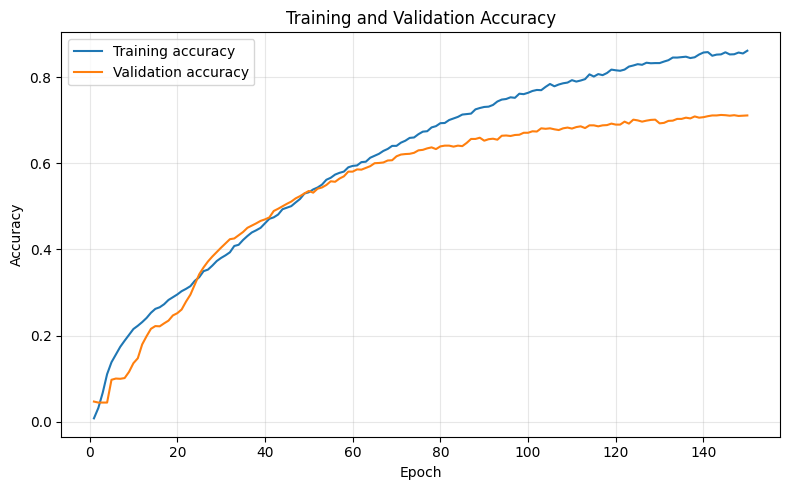

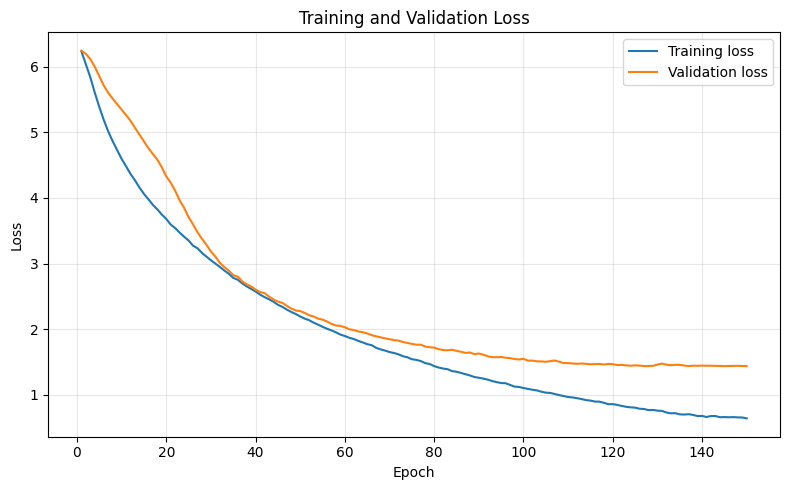

Curva accuracy guardada en: resultados_informe/fig_training_validation_accuracy.png
Curva loss guardada en: resultados_informe/fig_training_validation_loss.png


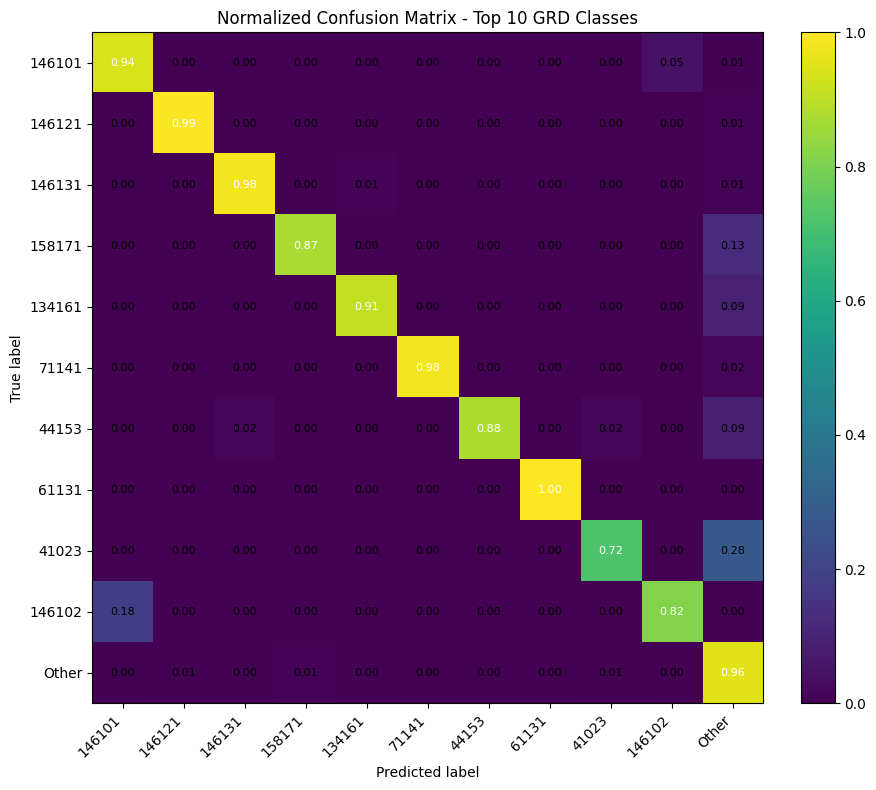

Matriz de confusión guardada en: resultados_informe/fig_confusion_matrix_top_10.png


,GRD,Precision,Recall,F1-score,Support
0,146101,0.922156,0.944785,0.933333,163.0
1,146121,0.927007,0.992188,0.958491,128.0
2,146131,0.954955,0.981481,0.968037,108.0
3,158171,1.000000,0.871795,0.931507,78.0
4,134161,0.967213,0.907692,0.936508,65.0
5,71141,1.000000,0.984127,0.992000,63.0
6,44153,1.000000,0.877193,0.934579,57.0
7,61131,1.000000,1.000000,1.000000,51.0
8,41023,0.947368,0.720000,0.818182,50.0
9,146102,0.769231,0.816327,0.792079,49.0


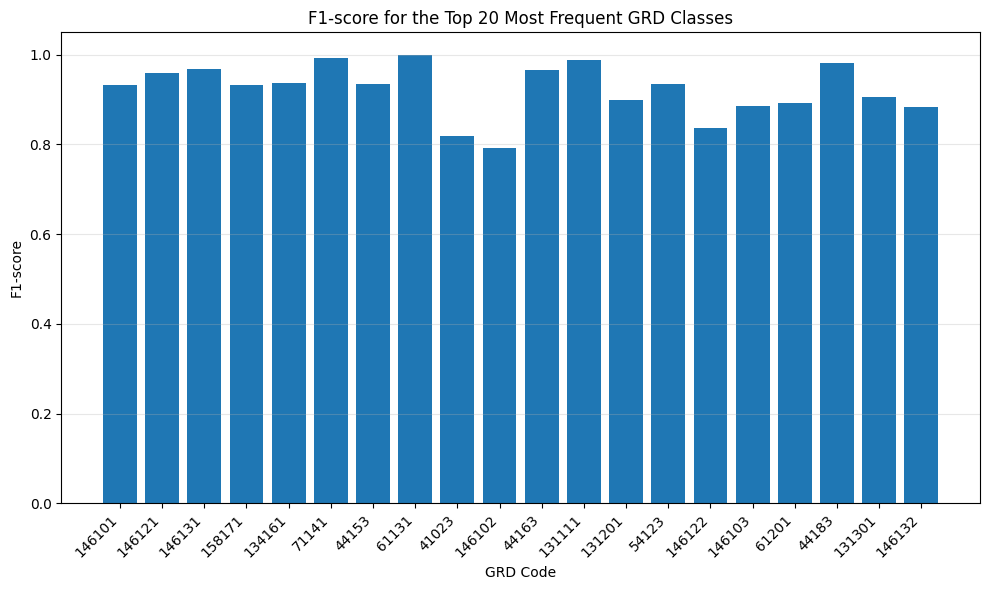

Reporte top 20 guardado en: resultados_informe/top20_grd_classification_report.csv
Gráfico F1 top 20 guardado en: resultados_informe/fig_top20_grd_f1_score.png


,Model,Accuracy
0,Baseline,0.373000
1,Random Forest,0.465200
2,Previous MLP,0.373000
3,Final NN with embeddings,0.702796


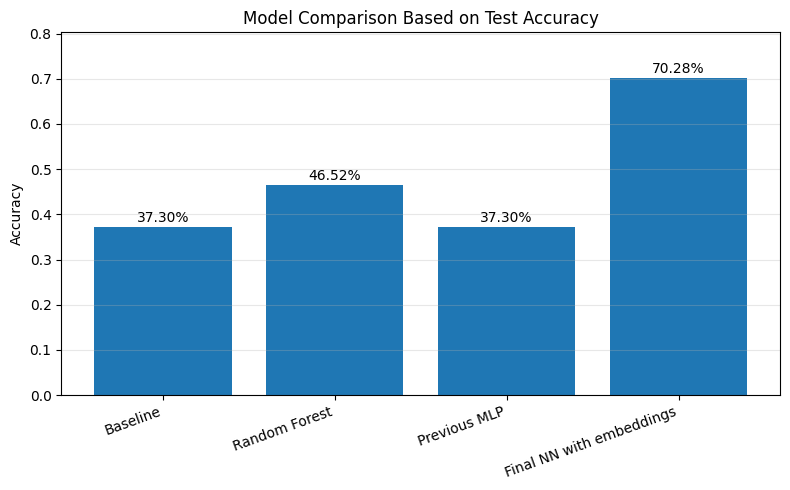

Comparación de modelos guardada en: resultados_informe/model_comparison.csv
Gráfico de comparación guardado en: resultados_informe/fig_model_comparison_accuracy.png


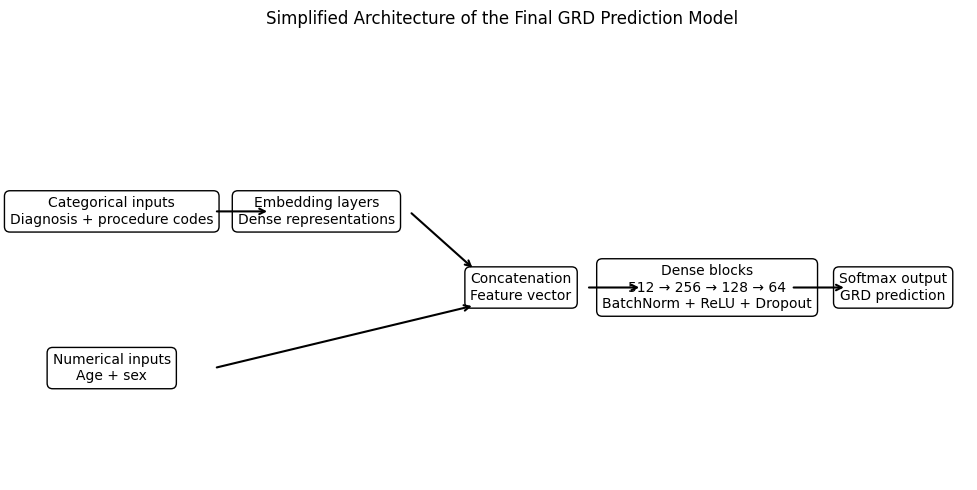

Diagrama de arquitectura guardado en: resultados_informe/fig_model_architecture_simplified.png

RESUMEN PARA INFORME
Test Accuracy        : 0.7028 (70.28%)
Macro Precision      : 0.3220
Macro Recall         : 0.3339
Macro F1-score       : 0.3173
Weighted F1-score    : 0.6806
Top-3 Accuracy       : 0.8329 (83.29%)
Top-5 Accuracy       : 0.8585 (85.85%)
Baseline Accuracy    : 0.3730 (37.30%)
Delta vs Baseline    : +32.98 percentage points
Epochs trained       : 150
Best validation loss : 1.4391

Archivos generados en la carpeta:
  resultados_informe/


In [6]:
# ============================================================
# VISUALIZACIONES Y MÉTRICAS FINALES PARA INFORME
# Pegar al final de MPL2.ipynb después de la evaluación
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    top_k_accuracy_score
)

# ------------------------------------------------------------
# Carpeta de salida para guardar figuras y tablas
# ------------------------------------------------------------

OUTPUT_DIR = "resultados_informe"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 70)
print("GENERANDO MÉTRICAS Y FIGURAS PARA EL INFORME")
print("=" * 70)


# ============================================================
# 1. MÉTRICAS FINALES GLOBALES
# ============================================================

acc = accuracy_score(true_grd, pred_grd)

precision_macro = precision_score(
    true_grd, pred_grd, average="macro", zero_division=0
)

recall_macro = recall_score(
    true_grd, pred_grd, average="macro", zero_division=0
)

f1_macro = f1_score(
    true_grd, pred_grd, average="macro", zero_division=0
)

precision_weighted = precision_score(
    true_grd, pred_grd, average="weighted", zero_division=0
)

recall_weighted = recall_score(
    true_grd, pred_grd, average="weighted", zero_division=0
)

f1_weighted = f1_score(
    true_grd, pred_grd, average="weighted", zero_division=0
)

# Top-k accuracy: útil porque en clasificación GRD puede ser relevante
# que el GRD correcto esté dentro de las primeras predicciones.
all_labels = np.arange(pred_probs.shape[1])

top3_acc = top_k_accuracy_score(
    true_grd, pred_probs, k=3, labels=all_labels
)

top5_acc = top_k_accuracy_score(
    true_grd, pred_probs, k=5, labels=all_labels
)

baseline = 0.3730
delta_vs_baseline = acc - baseline

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-score",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1-score",
        "Top-3 Accuracy",
        "Top-5 Accuracy",
        "Baseline Accuracy",
        "Delta vs Baseline"
    ],
    "Value": [
        acc,
        precision_macro,
        recall_macro,
        f1_macro,
        precision_weighted,
        recall_weighted,
        f1_weighted,
        top3_acc,
        top5_acc,
        baseline,
        delta_vs_baseline
    ]
})

metrics_path = os.path.join(OUTPUT_DIR, "final_metrics.csv")
metrics_df.to_csv(metrics_path, index=False)

print("\nMÉTRICAS FINALES")
display(metrics_df)

print(f"\nMétricas guardadas en: {metrics_path}")


# ============================================================
# 2. CURVAS DE ENTRENAMIENTO
# ============================================================

history_dict = history.history
epochs = range(1, len(history_dict["loss"]) + 1)

# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, history_dict["accuracy"], label="Training accuracy")
plt.plot(epochs, history_dict["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

acc_curve_path = os.path.join(OUTPUT_DIR, "fig_training_validation_accuracy.png")
plt.savefig(acc_curve_path, dpi=300, bbox_inches="tight")
plt.show()

# Loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, history_dict["loss"], label="Training loss")
plt.plot(epochs, history_dict["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

loss_curve_path = os.path.join(OUTPUT_DIR, "fig_training_validation_loss.png")
plt.savefig(loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Curva accuracy guardada en: {acc_curve_path}")
print(f"Curva loss guardada en: {loss_curve_path}")


# ============================================================
# 3. MATRIZ DE CONFUSIÓN PARA TOP-K GRD MÁS FRECUENTES
# ============================================================

# Para el informe conviene TOP_K = 10 porque queda más legible.
# Si quieren más detalle, pueden cambiarlo a 20.
TOP_K = 10

top_classes = [cls for cls, _ in Counter(true_grd).most_common(TOP_K)]
other_label = -1

def map_to_top_or_other(y, top_classes, other_label=-1):
    """
    Convierte clases fuera del top-k en una categoría 'Other',
    para que la matriz de confusión no ignore errores hacia clases raras.
    """
    top_set = set(top_classes)
    return np.array([label if label in top_set else other_label for label in y])

true_top = map_to_top_or_other(true_grd, top_classes, other_label)
pred_top = map_to_top_or_other(pred_grd, top_classes, other_label)

labels_for_cm = top_classes + [other_label]
display_labels = [str(le_grd.classes_[i]) for i in top_classes] + ["Other"]

cm = confusion_matrix(
    true_top,
    pred_top,
    labels=labels_for_cm,
    normalize="true"
)

plt.figure(figsize=(10, 8))
im = plt.imshow(cm, interpolation="nearest")
plt.title(f"Normalized Confusion Matrix - Top {TOP_K} GRD Classes")
plt.colorbar(im, fraction=0.046, pad=0.04)

tick_marks = np.arange(len(display_labels))
plt.xticks(tick_marks, display_labels, rotation=45, ha="right")
plt.yticks(tick_marks, display_labels)

plt.xlabel("Predicted label")
plt.ylabel("True label")

# Anotar valores dentro de la matriz
threshold = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm[i, j]
        plt.text(
            j, i, f"{value:.2f}",
            ha="center", va="center",
            color="white" if value > threshold else "black",
            fontsize=8
        )

plt.tight_layout()

cm_path = os.path.join(OUTPUT_DIR, f"fig_confusion_matrix_top_{TOP_K}.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Matriz de confusión guardada en: {cm_path}")


# ============================================================
# 4. F1-SCORE POR CLASE PARA LOS GRD MÁS FRECUENTES
# ============================================================

TOP_REPORT = 20

top20 = [idx for idx, _ in Counter(true_grd).most_common(TOP_REPORT)]
mask_top20 = np.isin(true_grd, top20)

report_dict = classification_report(
    true_grd[mask_top20],
    pred_grd[mask_top20],
    labels=top20,
    target_names=[str(le_grd.classes_[i]) for i in top20],
    zero_division=0,
    output_dict=True
)

rows = []
for class_id in [str(le_grd.classes_[i]) for i in top20]:
    rows.append({
        "GRD": class_id,
        "Precision": report_dict[class_id]["precision"],
        "Recall": report_dict[class_id]["recall"],
        "F1-score": report_dict[class_id]["f1-score"],
        "Support": report_dict[class_id]["support"]
    })

top20_df = pd.DataFrame(rows)
top20_path = os.path.join(OUTPUT_DIR, "top20_grd_classification_report.csv")
top20_df.to_csv(top20_path, index=False)

display(top20_df)

plt.figure(figsize=(10, 6))
plt.bar(top20_df["GRD"], top20_df["F1-score"])
plt.xlabel("GRD Code")
plt.ylabel("F1-score")
plt.title("F1-score for the Top 20 Most Frequent GRD Classes")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

f1_top20_path = os.path.join(OUTPUT_DIR, "fig_top20_grd_f1_score.png")
plt.savefig(f1_top20_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Reporte top 20 guardado en: {top20_path}")
print(f"Gráfico F1 top 20 guardado en: {f1_top20_path}")


# ============================================================
# 5. COMPARACIÓN DE MODELOS
# ============================================================

# IMPORTANTE:
# Ajustar estos valores si sus resultados finales cambian.
# Los valores aquí están basados en los resultados que ya tienen:
# - Baseline: 37.30%
# - Random Forest mejor: 46.52%
# - MLP multi-output anterior: aprox. 37.3% en GRD
# - Modelo final MPL2: accuracy calculada en este notebook

model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Random Forest",
        "Previous MLP",
        "Final NN with embeddings"
    ],
    "Accuracy": [
        baseline,
        0.4652,
        0.3730,
        acc
    ]
})

comparison_path = os.path.join(OUTPUT_DIR, "model_comparison.csv")
model_comparison.to_csv(comparison_path, index=False)

display(model_comparison)

plt.figure(figsize=(8, 5))
plt.bar(model_comparison["Model"], model_comparison["Accuracy"])
plt.ylabel("Accuracy")
plt.title("Model Comparison Based on Test Accuracy")
plt.ylim(0, max(model_comparison["Accuracy"]) + 0.1)
plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(model_comparison["Accuracy"]):
    plt.text(i, value + 0.01, f"{value*100:.2f}%", ha="center")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

comparison_fig_path = os.path.join(OUTPUT_DIR, "fig_model_comparison_accuracy.png")
plt.savefig(comparison_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Comparación de modelos guardada en: {comparison_path}")
print(f"Gráfico de comparación guardado en: {comparison_fig_path}")


# ============================================================
# 6. DIAGRAMA SIMPLIFICADO DE ARQUITECTURA
# ============================================================

# Este diagrama es más limpio para el informe que plot_model(),
# porque el modelo tiene muchas entradas categóricas y plot_model puede
# generar una figura demasiado grande.

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")

boxes = [
    ("Categorical inputs\nDiagnosis + procedure codes", 0.08, 0.60),
    ("Embedding layers\nDense representations", 0.30, 0.60),
    ("Numerical inputs\nAge + sex", 0.08, 0.25),
    ("Concatenation\nFeature vector", 0.52, 0.43),
    ("Dense blocks\n512 → 256 → 128 → 64\nBatchNorm + ReLU + Dropout", 0.72, 0.43),
    ("Softmax output\nGRD prediction", 0.92, 0.43),
]

for text, x, y in boxes:
    ax.text(
        x, y, text,
        ha="center", va="center",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", edgecolor="black", facecolor="white")
    )

arrows = [
    ((0.19, 0.60), (0.25, 0.60)),
    ((0.40, 0.60), (0.47, 0.47)),
    ((0.19, 0.25), (0.47, 0.39)),
    ((0.59, 0.43), (0.65, 0.43)),
    ((0.81, 0.43), (0.87, 0.43)),
]

for start, end in arrows:
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(arrowstyle="->", lw=1.5)
    )

plt.title("Simplified Architecture of the Final GRD Prediction Model")
plt.tight_layout()

architecture_path = os.path.join(OUTPUT_DIR, "fig_model_architecture_simplified.png")
plt.savefig(architecture_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Diagrama de arquitectura guardado en: {architecture_path}")


# ============================================================
# 7. RESUMEN FINAL EN CONSOLA
# ============================================================

print("\n" + "=" * 70)
print("RESUMEN PARA INFORME")
print("=" * 70)
print(f"Test Accuracy        : {acc:.4f} ({acc*100:.2f}%)")
print(f"Macro Precision      : {precision_macro:.4f}")
print(f"Macro Recall         : {recall_macro:.4f}")
print(f"Macro F1-score       : {f1_macro:.4f}")
print(f"Weighted F1-score    : {f1_weighted:.4f}")
print(f"Top-3 Accuracy       : {top3_acc:.4f} ({top3_acc*100:.2f}%)")
print(f"Top-5 Accuracy       : {top5_acc:.4f} ({top5_acc*100:.2f}%)")
print(f"Baseline Accuracy    : {baseline:.4f} ({baseline*100:.2f}%)")
print(f"Delta vs Baseline    : {delta_vs_baseline*100:+.2f} percentage points")
print(f"Epochs trained       : {len(history.history['loss'])}")
print(f"Best validation loss : {min(history.history['val_loss']):.4f}")
print("=" * 70)

print("\nArchivos generados en la carpeta:")
print(f"  {OUTPUT_DIR}/")

In [7]:
# ============================================================
# DESCARGAR RESULTADOS COMO ZIP DESDE COLAB
# ============================================================

import shutil
from google.colab import files

zip_path = shutil.make_archive("resultados_informe", "zip", OUTPUT_DIR)
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>